# [12.1] CLIP, SigLIP, and VLM Controls

> **ARENA extension note.** Original ARENA is unchanged. This section builds an exact contrastive model organism before opening pinned CLIP, SigLIP, and Qwen2.5-VL computations.

By the end of this notebook, you will have shown that paired image-text representations support retrieval and that visual object tokens causally carry the answer, because learner-computed object patches flip the contrastive margin while background and same-size random controls do not.

## Core Question

When a real vision-language model matches an image to text, can you recover the embeddings yourself and then identify which visual tokens causally carry the match?

**Common bug:** treating a diagonal heatmap, an attention map, or a precomputed report as the method. Here you write the extraction, hook, patch, and causal-metric code; the report only records the separately reproduced CUDA outputs while this CPU notebook is executed.

## Learning Objectives

You will learn to:

1. implement CLIP cosine logits and SigLIP's pairwise logistic objective;
2. train and falsify a tiny CLIP on inspectable colored-shape pairs;
3. extract normalized embeddings from pinned CLIP-like towers;
4. compute bidirectional retrieval accuracy and positive-pair margins;
5. construct object, background, random, and full-sequence patches;
6. register and remove activation hooks without leaking state;
7. replace selected hidden visual-token rows and compute causal effects; and
8. trim prompt tokens and score Qwen's generated answers.


In [1]:
import json
import sys
from collections.abc import Callable, Mapping
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch as t
import torch.nn.functional as F
from IPython.display import display

GT_TIER = "GT-1"
EXERCISE_ID = "12_1_clip_siglip_and_vlm_controls"
DIFFICULTY = 4
IMPORTANCE = 3
EXPECTED_RUNTIME = "75-105 minutes; optional pinned real-model cells require CUDA"
REQUIRES_GPU = True

chapter = "chapter12_vlm_interpretability"
section = "part1_clip_siglip_vlm_controls"
root_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / chapter).exists())
exercises_dir = root_dir / chapter / "exercises"
section_dir = exercises_dir / section
assets_dir = root_dir / chapter / "instructions" / "assets"
for path in (root_dir, exercises_dir):
    if str(path) not in sys.path:
        sys.path.append(str(path))

import part1_clip_siglip_vlm_controls.tests as tests
from arena_ext.vlm_interpretability import (
    ContrastiveAlignmentReport,
    ToyCLIPTrainingResult,
    build_toy_clip_batch,
    deterministic_derangement,
    same_size_non_overlapping_token_control,
    toy_caption_features,
)

RUN_REAL_MODELS = False
REAL_MODELS = {
    "CLIP": (
        "openai/clip-vit-base-patch32",
        "3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268",
        32,
        True,
    ),
    "SigLIP": (
        "google/siglip-base-patch16-224",
        "7fd15f0689c79d79e38b1c2e2e2370a7bf2761ed",
        16,
        False,
    ),
}
QWEN_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
QWEN_REVISION = "66285546d2b821cf421d4f5eb2576359d3770cd3"
TEXTS = (
    "a simple red square on a white background",
    "a simple blue circle on a white background",
)
OBJECT_BBOX = (76, 76, 148, 148)
BACKGROUND_BBOX = (0, 0, 40, 40)


## Cold Open: Inspect the Evidence Before the Model

The finite world below contains twelve paired images and captions. A useful representation must retrieve the exact pair, reject deranged captions, and reject a caption that preserves shape but changes color. This toy task is ground truth for the evaluation code used on real checkpoints later.


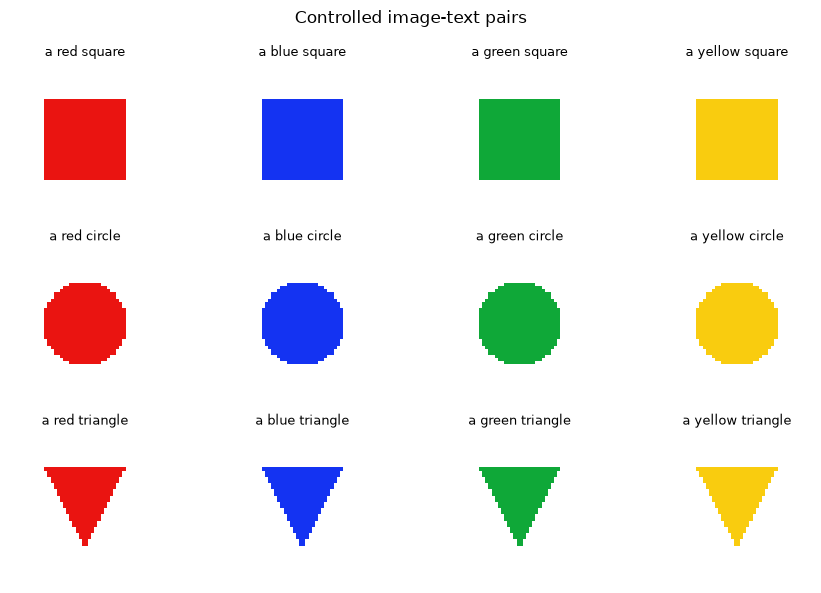

In [2]:
toy_batch = build_toy_clip_batch(
    colors=("red", "blue", "green", "yellow"),
    shapes=("square", "circle", "triangle"),
    image_size=48,
)
fig, axes = plt.subplots(3, 4, figsize=(9, 6))
for ax, image, caption in zip(axes.flat, toy_batch.image_tensors, toy_batch.captions):
    ax.imshow(image.permute(1, 2, 0).numpy())
    ax.set_title(caption, fontsize=9)
    ax.axis("off")
fig.suptitle("Controlled image-text pairs")
plt.tight_layout()
plt.show()


### Exercise 1 - CLIP similarity and a falsifiable retrieval report

Implement normalized all-pairs cosine logits, then require both retrieval directions and the diagonal-to-strongest-distractor margin. Test first on an exact orthogonal basis.


In [3]:
def _normalize(values: t.Tensor) -> t.Tensor:
    values = values.float()
    return values / values.norm(dim=-1, keepdim=True).clamp_min(1e-8)


def clip_contrastive_logits(
    image_embeddings: t.Tensor,
    text_embeddings: t.Tensor,
    *,
    logit_scale: float = 10.0,
) -> t.Tensor:
    if image_embeddings.ndim != 2 or text_embeddings.ndim != 2:
        raise ValueError("embeddings must be rank-2 matrices.")
    if image_embeddings.shape[1] != text_embeddings.shape[1]:
        raise ValueError("image and text embedding widths must match.")
    return logit_scale * (_normalize(image_embeddings) @ _normalize(text_embeddings).T)


def contrastive_alignment_report(
    logits: t.Tensor,
    *,
    min_accuracy: float = 1.0,
    min_positive_margin: float = 1.0,
) -> ContrastiveAlignmentReport:
    if logits.ndim != 2 or logits.shape[0] != logits.shape[1]:
        raise ValueError("paired retrieval logits must be square.")
    targets = t.arange(logits.shape[0], device=logits.device)
    image_accuracy = float((logits.argmax(dim=1) == targets).float().mean())
    text_accuracy = float((logits.argmax(dim=0) == targets).float().mean())
    diagonal = logits.diag()
    mask = t.eye(logits.shape[0], dtype=t.bool, device=logits.device)
    strongest_image_negative = logits.masked_fill(mask, float("-inf")).max(dim=1).values
    strongest_text_negative = logits.masked_fill(mask, float("-inf")).max(dim=0).values
    margin = float(t.cat([diagonal - strongest_image_negative, diagonal - strongest_text_negative]).mean())
    return ContrastiveAlignmentReport(
        image_to_text_accuracy=image_accuracy,
        text_to_image_accuracy=text_accuracy,
        mean_positive_margin=margin,
        aligned=image_accuracy >= min_accuracy and text_accuracy >= min_accuracy and margin >= min_positive_margin,
    )


In [4]:
def contrastive_smoke_test():
    logits = clip_contrastive_logits(t.eye(3), t.eye(3), logit_scale=5.0)
    return contrastive_alignment_report(logits, min_positive_margin=4.0).__dict__

tests.test_contrastive_smoke_test(contrastive_smoke_test)


All tests in `test_contrastive_smoke_test` passed!


<details>
        <summary>Expected output</summary>

        Both retrieval accuracies are `1.0` and the exact margin is `5.0`.

        </details>

        <details>
        <summary>Help - reason about the invariant</summary>

        Normalize each row before multiplying. Mask the diagonal only when finding the strongest negative.

        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def _normalize(values: t.Tensor) -> t.Tensor:
    values = values.float()
    return values / values.norm(dim=-1, keepdim=True).clamp_min(1e-8)


def clip_contrastive_logits(
    image_embeddings: t.Tensor,
    text_embeddings: t.Tensor,
    *,
    logit_scale: float = 10.0,
) -> t.Tensor:
    if image_embeddings.ndim != 2 or text_embeddings.ndim != 2:
        raise ValueError("embeddings must be rank-2 matrices.")
    if image_embeddings.shape[1] != text_embeddings.shape[1]:
        raise ValueError("image and text embedding widths must match.")
    return logit_scale * (_normalize(image_embeddings) @ _normalize(text_embeddings).T)


def contrastive_alignment_report(
    logits: t.Tensor,
    *,
    min_accuracy: float = 1.0,
    min_positive_margin: float = 1.0,
) -> ContrastiveAlignmentReport:
    if logits.ndim != 2 or logits.shape[0] != logits.shape[1]:
        raise ValueError("paired retrieval logits must be square.")
    targets = t.arange(logits.shape[0], device=logits.device)
    image_accuracy = float((logits.argmax(dim=1) == targets).float().mean())
    text_accuracy = float((logits.argmax(dim=0) == targets).float().mean())
    diagonal = logits.diag()
    mask = t.eye(logits.shape[0], dtype=t.bool, device=logits.device)
    strongest_image_negative = logits.masked_fill(mask, float("-inf")).max(dim=1).values
    strongest_text_negative = logits.masked_fill(mask, float("-inf")).max(dim=0).values
    margin = float(t.cat([diagonal - strongest_image_negative, diagonal - strongest_text_negative]).mean())
    return ContrastiveAlignmentReport(
        image_to_text_accuracy=image_accuracy,
        text_to_image_accuracy=text_accuracy,
        mean_positive_margin=margin,
        aligned=image_accuracy >= min_accuracy and text_accuracy >= min_accuracy and margin >= min_positive_margin,
    )
        ```

        </details>

        <details>
        <summary>Interpretation</summary>

        The matrix is evidence only because its pairing and strongest-distractor margin are known exactly.

        </details>


### Exercise 2 - SigLIP pairwise loss

Turn matching pairs into `+1`, mismatches into `-1`, and penalize every signed logit independently.


In [5]:
def siglip_pairwise_loss(logits: t.Tensor, labels: t.Tensor) -> t.Tensor:
    if logits.shape != labels.shape:
        raise ValueError("logits and labels must have the same shape.")
    signed_labels = t.where(labels > 0, 1.0, -1.0).to(logits)
    return F.softplus(-signed_labels * logits).mean()


In [6]:
def siglip_smoke_test():
    logits = t.tensor([[4.0, -4.0], [-3.0, 3.0]])
    return {"loss": float(siglip_pairwise_loss(logits, t.eye(2)))}

tests.test_siglip_smoke_test(siglip_smoke_test)


All tests in `test_siglip_smoke_test` passed!


<details>
    <summary>Expected output</summary>

    The exact pairwise loss is approximately `0.03337`.

    </details>

    <details>
    <summary>Help - reason about the invariant</summary>

    Use `softplus(-label * logit)` so correct positive and negative pairs both have small loss.

    </details>

    <details>
    <summary>Solution</summary>

    ```python
    def siglip_pairwise_loss(logits: t.Tensor, labels: t.Tensor) -> t.Tensor:
if logits.shape != labels.shape:
    raise ValueError("logits and labels must have the same shape.")
signed_labels = t.where(labels > 0, 1.0, -1.0).to(logits)
return F.softplus(-signed_labels * logits).mean()
    ```

    </details>

    <details>
    <summary>Interpretation</summary>

    Unlike CLIP's batch softmax, each SigLIP pair is an independent binary decision.

    </details>


### Exercise 3 - Train a tiny CLIP before trusting a checkpoint

Learn separate image and text projections on the rendered grid. The code must optimize the same all-pairs logits you just implemented.


In [7]:
def train_toy_clip_projectors(
    image_features: t.Tensor,
    text_features: t.Tensor,
    *,
    embedding_dim: int = 8,
    steps: int = 250,
    lr: float = 0.05,
    seed: int = 0,
) -> ToyCLIPTrainingResult:
    generator = t.Generator(device="cpu").manual_seed(seed)
    image_projection = t.nn.Parameter(t.randn(image_features.shape[1], embedding_dim, generator=generator) / image_features.shape[1]**0.5)
    text_projection = t.nn.Parameter(t.randn(text_features.shape[1], embedding_dim, generator=generator) / text_features.shape[1]**0.5)
    optimizer = t.optim.Adam([image_projection, text_projection], lr=lr)
    targets = t.arange(image_features.shape[0])
    losses = []
    for _ in range(steps):
        logits = clip_contrastive_logits(image_features @ image_projection, text_features @ text_projection)
        loss = (F.cross_entropy(logits, targets) + F.cross_entropy(logits.T, targets)) / 2
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach()))
    with t.no_grad():
        image_embeddings = image_features @ image_projection
        text_embeddings = text_features @ text_projection
        logits = clip_contrastive_logits(image_embeddings, text_embeddings)
        report = contrastive_alignment_report(logits)
    return ToyCLIPTrainingResult(
        image_projection=image_projection.detach(),
        text_projection=text_projection.detach(),
        image_embeddings=image_embeddings.detach(),
        text_embeddings=text_embeddings.detach(),
        retrieval_logits=logits.detach(),
        train_losses=tuple(losses),
        report=report,
    )


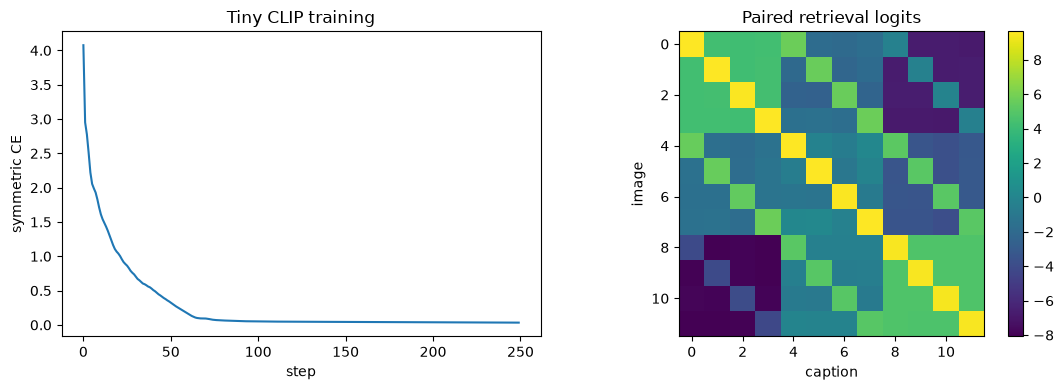

In [8]:
trained = train_toy_clip_projectors(toy_batch.image_features, toy_batch.text_features)
assert trained.train_losses[-1] < 0.1 * trained.train_losses[0], "The contrastive loss should fall by at least 90%."
assert trained.report.aligned, "The trained toy CLIP should retrieve all paired examples."
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(trained.train_losses)
axes[0].set(title="Tiny CLIP training", xlabel="step", ylabel="symmetric CE")
heat = axes[1].imshow(trained.retrieval_logits, cmap="viridis")
axes[1].set(title="Paired retrieval logits", xlabel="caption", ylabel="image")
fig.colorbar(heat, ax=axes[1])
plt.tight_layout(); plt.show()


<details>
        <summary>Expected output</summary>

        Loss falls by more than 90%; both paired retrieval accuracies reach `1.0`.

        </details>

        <details>
        <summary>Help - reason about the invariant</summary>

        Optimize two projection matrices jointly with image-to-text and text-to-image cross entropy.

        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def train_toy_clip_projectors(
    image_features: t.Tensor,
    text_features: t.Tensor,
    *,
    embedding_dim: int = 8,
    steps: int = 250,
    lr: float = 0.05,
    seed: int = 0,
) -> ToyCLIPTrainingResult:
    generator = t.Generator(device="cpu").manual_seed(seed)
    image_projection = t.nn.Parameter(t.randn(image_features.shape[1], embedding_dim, generator=generator) / image_features.shape[1]**0.5)
    text_projection = t.nn.Parameter(t.randn(text_features.shape[1], embedding_dim, generator=generator) / text_features.shape[1]**0.5)
    optimizer = t.optim.Adam([image_projection, text_projection], lr=lr)
    targets = t.arange(image_features.shape[0])
    losses = []
    for _ in range(steps):
        logits = clip_contrastive_logits(image_features @ image_projection, text_features @ text_projection)
        loss = (F.cross_entropy(logits, targets) + F.cross_entropy(logits.T, targets)) / 2
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach()))
    with t.no_grad():
        image_embeddings = image_features @ image_projection
        text_embeddings = text_features @ text_projection
        logits = clip_contrastive_logits(image_embeddings, text_embeddings)
        report = contrastive_alignment_report(logits)
    return ToyCLIPTrainingResult(
        image_projection=image_projection.detach(),
        text_projection=text_projection.detach(),
        image_embeddings=image_embeddings.detach(),
        text_embeddings=text_embeddings.detach(),
        retrieval_logits=logits.detach(),
        train_losses=tuple(losses),
        report=report,
    )
        ```

        </details>

        <details>
        <summary>Interpretation</summary>

        The heatmap should be read together with loss and retrieval metrics, not as a decorative diagonal.

        </details>


### Exercise 4 - Break the toy claim with controls

Derange captions and replace each color word with a counterfactual color. Compute the same report without changing its thresholds.


In [9]:
permutation = deterministic_derangement(len(toy_batch.captions), seed=0)
deranged_logits = clip_contrastive_logits(trained.image_embeddings, trained.text_embeddings[permutation])
conflict_captions = tuple(f"a {scene.counterfactual_answer} {scene.shape}" for scene in toy_batch.scenes)
conflict_features = toy_caption_features(conflict_captions, colors=toy_batch.colors, shapes=toy_batch.shapes)
conflict_embeddings = conflict_features @ trained.text_projection
conflict_logits = clip_contrastive_logits(trained.image_embeddings, conflict_embeddings)
control_rows = []
for name, logits in {"paired": trained.retrieval_logits, "deranged": deranged_logits, "wrong_color": conflict_logits}.items():
    result = contrastive_alignment_report(logits)
    control_rows.append({"condition": name, **result.__dict__})
display(pd.DataFrame(control_rows))
assert control_rows[0]["aligned"] and not control_rows[1]["aligned"] and not control_rows[2]["aligned"]


,condition,image_to_text_accuracy,text_to_image_accuracy,mean_positive_margin,aligned
0,paired,1.0,1.0,4.135524,True
1,deranged,0.0,0.0,-10.549884,False
2,wrong_color,0.0,0.0,-6.719059,False


<details>
<summary>Expected output</summary>

Paired retrieval passes; deranged and wrong-color conditions fail the same gate.

</details>

<details>
<summary>Help - reason about the invariant</summary>

Do not retrain for a control. Change only the pairing or caption evidence and reuse the metric.

</details>

<details>
<summary>Solution</summary>

```python
# The complete control computation is the code cell directly above.
```

</details>

<details>
<summary>Interpretation</summary>

A model that still passes after caption derangement has not established paired cross-modal alignment.

</details>


## Real Checkpoints: You Own the Computation

The remaining exercises use the same operations on pinned CLIP and SigLIP checkpoints. Weight loading and deterministic image rendering are plumbing; embedding extraction, retrieval, hooks, interventions, controls, and metrics remain learner code.


### Exercise 5 - Extract real image and text embeddings

Call each tower explicitly, normalize its output, and compute both retrieval directions. Do not use a preassembled report.


In [10]:
def extract_contrastive_embeddings(
    model,
    batch: Mapping[str, t.Tensor],
) -> tuple[t.Tensor, t.Tensor]:
    if "pixel_values" not in batch or "input_ids" not in batch:
        raise KeyError("batch must contain pixel_values and input_ids.")
    image_output = model.get_image_features(pixel_values=batch["pixel_values"])
    text_kwargs = {"input_ids": batch["input_ids"]}
    if "attention_mask" in batch:
        text_kwargs["attention_mask"] = batch["attention_mask"]
    text_output = model.get_text_features(**text_kwargs)
    image = image_output if isinstance(image_output, t.Tensor) else image_output.pooler_output
    text = text_output if isinstance(text_output, t.Tensor) else text_output.pooler_output
    image, text = image.float(), text.float()
    return (
        image / image.norm(dim=-1, keepdim=True).clamp_min(1e-8),
        text / text.norm(dim=-1, keepdim=True).clamp_min(1e-8),
    )


def bidirectional_retrieval_metrics(
    image_embeddings: t.Tensor,
    text_embeddings: t.Tensor,
    *,
    logit_scale: float = 1.0,
    logit_bias: float | t.Tensor = 0.0,
) -> dict[str, object]:
    logits = clip_contrastive_logits(image_embeddings, text_embeddings, logit_scale=logit_scale)
    logits = logits + t.as_tensor(logit_bias, device=logits.device, dtype=logits.dtype)
    report = contrastive_alignment_report(logits, min_accuracy=0.0, min_positive_margin=float("-inf"))
    return {"logits": logits, **report.__dict__}


In [11]:
tests.test_extract_contrastive_embeddings_normalizes_both_towers(extract_contrastive_embeddings)
tests.test_bidirectional_retrieval_metrics_uses_both_directions(bidirectional_retrieval_metrics)


All tests in `test_extract_contrastive_embeddings_normalizes_both_towers` passed!
All tests in `test_bidirectional_retrieval_metrics_uses_both_directions` passed!


<details>
        <summary>Expected output</summary>

        The exact dual-encoder oracle returns identity embeddings and a margin of `5.0`.

        </details>

        <details>
        <summary>Help - reason about the invariant</summary>

        Pass only pixel values to the image tower and token fields to the text tower; normalize after extraction.

        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def extract_contrastive_embeddings(
    model,
    batch: Mapping[str, t.Tensor],
) -> tuple[t.Tensor, t.Tensor]:
    if "pixel_values" not in batch or "input_ids" not in batch:
        raise KeyError("batch must contain pixel_values and input_ids.")
    image = model.get_image_features(pixel_values=batch["pixel_values"])
    text_kwargs = {"input_ids": batch["input_ids"]}
    if "attention_mask" in batch:
        text_kwargs["attention_mask"] = batch["attention_mask"]
    text = model.get_text_features(**text_kwargs)
    image, text = image.float(), text.float()
    return (
        image / image.norm(dim=-1, keepdim=True).clamp_min(1e-8),
        text / text.norm(dim=-1, keepdim=True).clamp_min(1e-8),
    )


def bidirectional_retrieval_metrics(
    image_embeddings: t.Tensor,
    text_embeddings: t.Tensor,
    *,
    logit_scale: float = 1.0,
    logit_bias: float | t.Tensor = 0.0,
) -> dict[str, object]:
    logits = clip_contrastive_logits(image_embeddings, text_embeddings, logit_scale=logit_scale)
    logits = logits + t.as_tensor(logit_bias, device=logits.device, dtype=logits.dtype)
    report = contrastive_alignment_report(logits, min_accuracy=0.0, min_positive_margin=float("-inf"))
    return {"logits": logits, **report.__dict__}
        ```

        </details>

        <details>
        <summary>Interpretation</summary>

        This makes the shared embedding space a visible computation instead of a black-box `model(**inputs)` claim.

        </details>


### Exercise 6 - Construct image-region and token-region controls

Patch pixels inside a bounding box and map that box to every overlapping visual token. Preserve CLIP's class-token offset but omit it for SigLIP.


In [12]:
def patch_image_region(clean_image, corrupt_image, bbox: tuple[int, int, int, int]):
    patched = clean_image.copy()
    patched.paste(corrupt_image.crop(bbox), bbox)
    return patched


def bbox_to_visual_tokens(
    bbox: tuple[int, int, int, int],
    *,
    image_size: int,
    patch_size: int,
    has_cls_token: bool,
) -> tuple[int, ...]:
    x1, y1, x2, y2 = bbox
    if not (0 <= x1 < x2 <= image_size and 0 <= y1 < y2 <= image_size):
        raise ValueError("bbox must have positive area inside the image.")
    grid = image_size // patch_size
    offset = int(has_cls_token)
    indices = []
    for row in range(grid):
        for col in range(grid):
            px1, py1 = col * patch_size, row * patch_size
            px2, py2 = px1 + patch_size, py1 + patch_size
            if max(x1, px1) < min(x2, px2) and max(y1, py1) < min(y2, py2):
                indices.append(offset + row * grid + col)
    return tuple(indices)


In [13]:
assert bbox_to_visual_tokens(OBJECT_BBOX, image_size=224, patch_size=32, has_cls_token=True) == (17, 18, 19, 24, 25, 26, 31, 32, 33)
assert len(bbox_to_visual_tokens(OBJECT_BBOX, image_size=224, patch_size=16, has_cls_token=False)) == 36
print("Object token geometry is exact for CLIP and SigLIP.")


Object token geometry is exact for CLIP and SigLIP.


<details>
        <summary>Expected output</summary>

        CLIP maps the object to 9 patch tokens after its class token; SigLIP maps it to 36 tokens.

        </details>

        <details>
        <summary>Help - reason about the invariant</summary>

        Enumerate patch rectangles and use strict interval overlap. Add one only to patch-token indices when a class token is present.

        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def patch_image_region(clean_image, corrupt_image, bbox: tuple[int, int, int, int]):
    patched = clean_image.copy()
    patched.paste(corrupt_image.crop(bbox), bbox)
    return patched


def bbox_to_visual_tokens(
    bbox: tuple[int, int, int, int],
    *,
    image_size: int,
    patch_size: int,
    has_cls_token: bool,
) -> tuple[int, ...]:
    x1, y1, x2, y2 = bbox
    if not (0 <= x1 < x2 <= image_size and 0 <= y1 < y2 <= image_size):
        raise ValueError("bbox must have positive area inside the image.")
    grid = image_size // patch_size
    offset = int(has_cls_token)
    indices = []
    for row in range(grid):
        for col in range(grid):
            px1, py1 = col * patch_size, row * patch_size
            px2, py2 = px1 + patch_size, py1 + patch_size
            if max(x1, px1) < min(x2, px2) and max(y1, py1) < min(y2, py2):
                indices.append(offset + row * grid + col)
    return tuple(indices)
        ```

        </details>

        <details>
        <summary>Interpretation</summary>

        Token count is part of the causal claim: random controls must replace exactly the same number of rows.

        </details>


### Exercise 7 - Register a cache hook and replace hidden token rows

Capture exactly one tensor from the vision embedding module, remove the hook in a `finally` block, and replace only selected sequence rows.


In [14]:
def capture_module_output(
    module: t.nn.Module,
    forward_fn: Callable[[], object],
) -> tuple[object, t.Tensor]:
    captured = []
    def save_output(_module, _args, output):
        if not isinstance(output, t.Tensor):
            raise TypeError("the hook point must return a tensor.")
        captured.append(output.detach())
    handle = module.register_forward_hook(save_output)
    try:
        result = forward_fn()
    finally:
        handle.remove()
    if len(captured) != 1:
        raise RuntimeError(f"expected one activation, captured {len(captured)}.")
    return result, captured[0]


def patch_hidden_token_rows(
    clean_activations: t.Tensor,
    corrupt_activations: t.Tensor,
    token_indices: tuple[int, ...] | list[int],
) -> t.Tensor:
    if clean_activations.shape != corrupt_activations.shape or clean_activations.ndim != 3:
        raise ValueError("clean and corrupt activations need matching [batch, token, hidden] shape.")
    index = t.tensor(tuple(token_indices), device=clean_activations.device)
    if index.numel() == 0 or index.unique().numel() != index.numel():
        raise ValueError("token_indices must be nonempty and unique.")
    if index.min() < 0 or index.max() >= clean_activations.shape[1]:
        raise ValueError("token index out of range.")
    patched = clean_activations.clone()
    patched[:, index] = corrupt_activations[:, index].to(patched)
    return patched


In [15]:
tests.test_hook_cache_and_hidden_patch_are_causal(capture_module_output, patch_hidden_token_rows)


All tests in `test_hook_cache_and_hidden_patch_are_causal` passed!


<details>
        <summary>Expected output</summary>

        The exact linear module's activation is captured once; one selected row changes and all other rows remain clean.

        </details>

        <details>
        <summary>Help - reason about the invariant</summary>

        A hook is global mutable state. Always remove it even when the forward pass raises.

        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def capture_module_output(
    module: t.nn.Module,
    forward_fn: Callable[[], object],
) -> tuple[object, t.Tensor]:
    captured = []
    def save_output(_module, _args, output):
        if not isinstance(output, t.Tensor):
            raise TypeError("the hook point must return a tensor.")
        captured.append(output.detach())
    handle = module.register_forward_hook(save_output)
    try:
        result = forward_fn()
    finally:
        handle.remove()
    if len(captured) != 1:
        raise RuntimeError(f"expected one activation, captured {len(captured)}.")
    return result, captured[0]


def patch_hidden_token_rows(
    clean_activations: t.Tensor,
    corrupt_activations: t.Tensor,
    token_indices: tuple[int, ...] | list[int],
) -> t.Tensor:
    if clean_activations.shape != corrupt_activations.shape or clean_activations.ndim != 3:
        raise ValueError("clean and corrupt activations need matching [batch, token, hidden] shape.")
    index = t.tensor(tuple(token_indices), device=clean_activations.device)
    if index.numel() == 0 or index.unique().numel() != index.numel():
        raise ValueError("token_indices must be nonempty and unique.")
    if index.min() < 0 or index.max() >= clean_activations.shape[1]:
        raise ValueError("token index out of range.")
    patched = clean_activations.clone()
    patched[:, index] = corrupt_activations[:, index].to(patched)
    return patched
        ```

        </details>

        <details>
        <summary>Interpretation</summary>

        A localized activation intervention is meaningful only if unselected token rows are bit-for-bit unchanged.

        </details>


### Exercise 8 - Run a real activation patch

Compute corrupt visual embeddings once, register a temporary replacement hook, run the otherwise-clean model, and return its image-text logits.


In [16]:
def run_with_activation_patch(
    model,
    embedding_module: t.nn.Module,
    clean_inputs: Mapping[str, t.Tensor],
    corrupt_pixel_values: t.Tensor,
    token_indices: tuple[int, ...] | list[int],
) -> t.Tensor:
    with t.inference_mode():
        corrupt_activations = embedding_module(corrupt_pixel_values)
    def patch_hook(_module, _args, clean_activations):
        return patch_hidden_token_rows(clean_activations, corrupt_activations, token_indices)
    handle = embedding_module.register_forward_hook(patch_hook)
    try:
        with t.inference_mode():
            return model(**dict(clean_inputs)).logits_per_image.detach().float().cpu()
    finally:
        handle.remove()


<details>
        <summary>Expected output</summary>

        On the pinned runs, full-sequence patch logits match the corrupt forward pass to numerical precision.

        </details>

        <details>
        <summary>Help - reason about the invariant</summary>

        The patch hook must return a complete activation tensor with only selected rows changed.

        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def run_with_activation_patch(
    model,
    embedding_module: t.nn.Module,
    clean_inputs: Mapping[str, t.Tensor],
    corrupt_pixel_values: t.Tensor,
    token_indices: tuple[int, ...] | list[int],
) -> t.Tensor:
    with t.inference_mode():
        corrupt_activations = embedding_module(corrupt_pixel_values)
    def patch_hook(_module, _args, clean_activations):
        return patch_hidden_token_rows(clean_activations, corrupt_activations, token_indices)
    handle = embedding_module.register_forward_hook(patch_hook)
    try:
        with t.inference_mode():
            return model(**dict(clean_inputs)).logits_per_image.detach().float().cpu()
    finally:
        handle.remove()
        ```

        </details>

        <details>
        <summary>Interpretation</summary>

        Full-sequence parity is the integration oracle for the hook: if it fails, do not interpret object localization.

        </details>


### Exercise 9 - Compute causal effects and matched controls

Turn each logit matrix into target-minus-counterfactual margins, then compare object, background, same-size random, and full-sequence patches.


In [17]:
def causal_patch_metrics(
    clean_logits: t.Tensor,
    corrupt_logits: t.Tensor,
    patched_logits: Mapping[str, t.Tensor],
    *,
    target_indices: t.Tensor,
    counterfactual_indices: t.Tensor,
) -> dict[str, object]:
    def margins(logits: t.Tensor) -> t.Tensor:
        rows = t.arange(logits.shape[0], device=logits.device)
        return logits[rows, target_indices.to(logits.device)] - logits[rows, counterfactual_indices.to(logits.device)]
    clean = margins(clean_logits)
    corrupt = margins(corrupt_logits)
    rows = []
    for condition, logits in patched_logits.items():
        patched = margins(logits)
        rows.append({
            "condition": condition,
            "mean_margin": float(patched.mean()),
            "mean_effect": float((clean - patched).mean()),
            "all_flip": bool((patched < 0).all()),
        })
    return {"clean_margins": clean.tolist(), "corrupt_margins": corrupt.tolist(), "rows": rows}


In [18]:
tests.test_causal_patch_metrics_separates_object_from_controls(causal_patch_metrics)


All tests in `test_causal_patch_metrics_separates_object_from_controls` passed!


<details>
        <summary>Expected output</summary>

        Object and full-sequence conditions flip; background and same-size random controls preserve the exact oracle.

        </details>

        <details>
        <summary>Help - reason about the invariant</summary>

        Use the same target and counterfactual caption indices for every condition. Effect is clean margin minus patched margin.

        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def causal_patch_metrics(
    clean_logits: t.Tensor,
    corrupt_logits: t.Tensor,
    patched_logits: Mapping[str, t.Tensor],
    *,
    target_indices: t.Tensor,
    counterfactual_indices: t.Tensor,
) -> dict[str, object]:
    def margins(logits: t.Tensor) -> t.Tensor:
        rows = t.arange(logits.shape[0], device=logits.device)
        return logits[rows, target_indices.to(logits.device)] - logits[rows, counterfactual_indices.to(logits.device)]
    clean = margins(clean_logits)
    corrupt = margins(corrupt_logits)
    rows = []
    for condition, logits in patched_logits.items():
        patched = margins(logits)
        rows.append({
            "condition": condition,
            "mean_margin": float(patched.mean()),
            "mean_effect": float((clean - patched).mean()),
            "all_flip": bool((patched < 0).all()),
        })
    return {"clean_margins": clean.tolist(), "corrupt_margins": corrupt.tolist(), "rows": rows}
        ```

        </details>

        <details>
        <summary>Interpretation</summary>

        The object patch is localized evidence only when its effect exceeds both matched controls.

        </details>


### Exercise 10 - Decode Qwen answers without scoring the prompt

Generation returns prompt plus continuation. Trim the complete padded prompt width before decoding the answer, then use exact controlled labels.


In [19]:
def trim_generated_tokens(input_ids: t.Tensor, generated_ids: t.Tensor) -> list[t.Tensor]:
    if input_ids.ndim != 2 or generated_ids.ndim != 2 or input_ids.shape[0] != generated_ids.shape[0]:
        raise ValueError("input_ids and generated_ids need matching rank-2 batch axes.")
    return [output[len(prompt):] for prompt, output in zip(input_ids, generated_ids)]


def generate_qwen_answers(model, processor, inputs, *, max_new_tokens: int = 8) -> list[str]:
    with t.inference_mode():
        generated = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    trimmed = trim_generated_tokens(inputs.input_ids, generated)
    return [answer.strip().lower() for answer in processor.batch_decode(trimmed, skip_special_tokens=True)]


In [20]:
tests.test_trim_generated_tokens_removes_prompt_prefix(trim_generated_tokens)


All tests in `test_trim_generated_tokens_removes_prompt_prefix` passed!


<details>
        <summary>Expected output</summary>

        The exact token oracle keeps only the two generated tokens in each row.

        </details>

        <details>
        <summary>Help - reason about the invariant</summary>

        Slice every generated row at `len(prompt_row)`, not at the number of non-padding tokens.

        </details>

        <details>
        <summary>Solution</summary>

        ```python
        def trim_generated_tokens(input_ids: t.Tensor, generated_ids: t.Tensor) -> list[t.Tensor]:
    if input_ids.ndim != 2 or generated_ids.ndim != 2 or input_ids.shape[0] != generated_ids.shape[0]:
        raise ValueError("input_ids and generated_ids need matching rank-2 batch axes.")
    return [output[len(prompt):] for prompt, output in zip(input_ids, generated_ids)]


def generate_qwen_answers(model, processor, inputs, *, max_new_tokens: int = 8) -> list[str]:
    with t.inference_mode():
        generated = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    trimmed = trim_generated_tokens(inputs.input_ids, generated)
    return [answer.strip().lower() for answer in processor.batch_decode(trimmed, skip_special_tokens=True)]
        ```

        </details>

        <details>
        <summary>Interpretation</summary>

        Qwen is a bounded generation comparison here, not evidence for hidden-token localization.

        </details>


## Signature Result

The visible result is a ladder, not a JSON blob: exact toy training and failed caption controls establish the metric; pinned CLIP and SigLIP then show bidirectional retrieval plus large object-token effects over matched controls; Qwen answers the two rendered scenes exactly but is not used to support the localization claim.

![CLIP and SigLIP signature result](../../instructions/assets/clip_siglip_controls_signature_result.svg)


In [21]:
def render_real_shape(color: str, shape: str):
    from PIL import Image, ImageDraw
    image = Image.new("RGB", (224, 224), "white")
    draw = ImageDraw.Draw(image)
    if shape == "square":
        draw.rectangle(OBJECT_BBOX, fill=color)
    elif shape == "circle":
        draw.ellipse(OBJECT_BBOX, fill=color)
    else:
        raise ValueError("shape must be square or circle.")
    return image


def load_pinned_contrastive_model(kind: str, device: str = "cuda"):
    from huggingface_hub import snapshot_download
    from transformers import AutoProcessor, CLIPModel, CLIPProcessor, SiglipModel
    model_id, revision, _, _ = REAL_MODELS[kind]
    snapshot = snapshot_download(model_id, revision=revision)
    if kind == "CLIP":
        return CLIPModel.from_pretrained(snapshot).to(device).eval(), CLIPProcessor.from_pretrained(snapshot, use_fast=False)
    return SiglipModel.from_pretrained(snapshot, use_safetensors=True, dtype=t.float16).to(device).eval(), AutoProcessor.from_pretrained(snapshot, use_fast=False)


def run_real_contrastive_study(kind: str) -> dict[str, object]:
    model, processor = load_pinned_contrastive_model(kind)
    _, _, patch_size, has_cls = REAL_MODELS[kind]
    images = [render_real_shape("red", "square"), render_real_shape("blue", "circle")]
    corrupt_images = images[::-1]
    padding = "max_length" if kind == "SigLIP" else True
    clean_inputs = processor(text=list(TEXTS), images=images, return_tensors="pt", padding=padding).to("cuda")
    corrupt_inputs = processor(text=list(TEXTS), images=corrupt_images, return_tensors="pt", padding=padding).to("cuda")
    image_embeddings, text_embeddings = extract_contrastive_embeddings(model, clean_inputs)
    cosine = bidirectional_retrieval_metrics(image_embeddings, text_embeddings, logit_scale=float(model.logit_scale.exp().detach()), logit_bias=getattr(model, "logit_bias", 0.0))
    embedding_module = model.vision_model.embeddings
    object_indices = bbox_to_visual_tokens(OBJECT_BBOX, image_size=224, patch_size=patch_size, has_cls_token=has_cls)
    background_indices = bbox_to_visual_tokens(BACKGROUND_BBOX, image_size=224, patch_size=patch_size, has_cls_token=has_cls)
    _, sample_cache = capture_module_output(embedding_module, lambda: embedding_module(clean_inputs.pixel_values))
    random_indices = same_size_non_overlapping_token_control(
        object_indices,
        num_tokens=sample_cache.shape[1],
        protected_indices=tuple(background_indices) + ((0,) if has_cls else ()),
        seed=0,
    )
    full_indices = tuple(range(1 if has_cls else 0, sample_cache.shape[1]))
    with t.inference_mode():
        clean_logits = model(**clean_inputs).logits_per_image.detach().float().cpu()
        corrupt_logits = model(**{**clean_inputs, "pixel_values": corrupt_inputs.pixel_values}).logits_per_image.detach().float().cpu()
    patched = {
        name: run_with_activation_patch(model, embedding_module, clean_inputs, corrupt_inputs.pixel_values, indices)
        for name, indices in {
            "object": object_indices,
            "background": background_indices,
            "same_size_random": random_indices,
            "full_sequence": full_indices,
        }.items()
    }
    causal = causal_patch_metrics(
        clean_logits,
        corrupt_logits,
        patched,
        target_indices=t.tensor([0, 1]),
        counterfactual_indices=t.tensor([1, 0]),
    )
    return {"kind": kind, "cosine": cosine, "causal": causal, "object_indices": object_indices, "random_indices": random_indices}


def run_real_qwen_study() -> dict[str, object]:
    from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
    processor = AutoProcessor.from_pretrained(QWEN_ID, revision=QWEN_REVISION, min_pixels=224 * 224, max_pixels=224 * 224, use_fast=False)
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(QWEN_ID, revision=QWEN_REVISION, dtype=t.bfloat16, device_map="cuda", attn_implementation="eager").eval()
    images = [render_real_shape("red", "square"), render_real_shape("blue", "circle")]
    messages = [[{"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": "Answer with two lowercase words: color shape."}]}] for image in images]
    prompts = [processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True) for message in messages]
    inputs = processor(text=prompts, images=images, return_tensors="pt", padding=True).to("cuda")
    answers = generate_qwen_answers(model, processor, inputs)
    expected = ["red square", "blue circle"]
    return {"answers": answers, "expected": expected, "accuracy": sum(answer == target for answer, target in zip(answers, expected)) / len(expected)}


In [22]:
if RUN_REAL_MODELS:
    real_results = {kind: run_real_contrastive_study(kind) for kind in REAL_MODELS}
    for kind, result in real_results.items():
        display(pd.DataFrame(result["causal"]["rows"]).assign(model=kind))
    qwen_result = run_real_qwen_study()
    display(pd.DataFrame({"expected": qwen_result["expected"], "Qwen answer": qwen_result["answers"]}))
else:
    report = json.loads((section_dir / "verification_report.json").read_text())
    gpu = report["metrics"]["gpu_test"]
    real_rows = [
        {"model": "CLIP", "retrieval_i2t": gpu["real_clip_image_to_text_accuracy"], "retrieval_t2i": gpu["real_clip_text_to_image_accuracy"], "object_gap_vs_background": gpu["real_clip_activation_patch_min_object_gap_over_background"], "object_gap_vs_random": gpu["real_clip_activation_patch_min_object_gap_over_random"]},
        {"model": "SigLIP", "retrieval_i2t": gpu["real_siglip_image_to_text_accuracy"], "retrieval_t2i": gpu["real_siglip_text_to_image_accuracy"], "object_gap_vs_background": gpu["real_siglip_activation_patch_min_object_gap_over_background"], "object_gap_vs_random": gpu["real_siglip_activation_patch_min_object_gap_over_random"]},
    ]
    display(pd.DataFrame(real_rows))
    display(pd.DataFrame({"expected": gpu["real_qwen25_vl_expected_answers"], "Qwen answer": gpu["real_qwen25_vl_answers"]}))
    print("Set RUN_REAL_MODELS=True to regenerate these rows with your implementations.")


def run_gpu_test(max_vram_gb: float = 24.0) -> dict[str, object]:
    if not t.cuda.is_available():
        raise RuntimeError("12.1 real-model study requires CUDA.")
    t.cuda.reset_peak_memory_stats()
    result = {"contrastive": {kind: run_real_contrastive_study(kind) for kind in REAL_MODELS}, "qwen": run_real_qwen_study()}
    result["peak_vram_gb"] = t.cuda.max_memory_allocated() / 1024**3
    result["within_vram_budget"] = result["peak_vram_gb"] <= max_vram_gb
    return result


def run_full_experiment(max_vram_gb: float = 24.0) -> dict[str, object]:
    return run_gpu_test(max_vram_gb=max_vram_gb)


,model,retrieval_i2t,retrieval_t2i,object_gap_vs_background,object_gap_vs_random
0,CLIP,1.0,1.0,14.930391,14.930391
1,SigLIP,1.0,1.0,31.445312,31.445312


,expected,Qwen answer
0,red square,red square
1,blue circle,blue circle


Set RUN_REAL_MODELS=True to regenerate these rows with your implementations.


## Try It Yourself

Change one variable at a time: move `OBJECT_BBOX`, use `BACKGROUND_BBOX` as the purported object, swap only color while preserving shape, or replace `kind = "CLIP"` with `"SigLIP"`. Predict the target margin before running.

```python
kind = "CLIP"
play_bbox = OBJECT_BBOX
play_indices = bbox_to_visual_tokens(play_bbox, image_size=224, patch_size=REAL_MODELS[kind][2], has_cls_token=REAL_MODELS[kind][3])
print(kind, play_bbox, play_indices)
```

## Interpreting the Result

- **Retrieval success** says paired representations align on this controlled set.
- **Object patch flips** say counterfactual evidence in object-token rows is causally sufficient to reverse the pairwise choice.
- **Background and same-size random preservation** reject patch-size and generic-perturbation explanations.
- **Full-sequence parity** validates the hook and replacement mechanism.
- **Qwen generation** is behavioral grounding only; it does not localize a mechanism.

## Bonus: Hunt an Anomaly

Translate the shape until its box straddles patch boundaries. Does a larger token set dilute the object-vs-control gap? Repeat across seeds for the same-size random control and report the complete distribution, not the most favorable seed.

## Limitations

The real-model evidence uses two controlled rendered images, so it is a pinned mechanistic preflight rather than a broad claim about natural-image retrieval, hallucination, or VLM reasoning. Qwen is checked behaviorally on two safe prompts. A research-grade extension needs at least twenty held-out counterfactual scenes, natural-image controls, multiple hook points, and uncertainty across examples and random control sets.

## Reading Links

- [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/abs/2103.00020)
- [Sigmoid Loss for Language Image Pre-Training](https://arxiv.org/abs/2303.15343)
- [Qwen2.5-VL Technical Report](https://arxiv.org/abs/2502.13923)
- [Transformer Circuits: activation patching](https://transformer-circuits.pub/2021/framework/index.html)

## Verification Appendix

`verification_report.json` records the post-rewrite CUDA 13.2 run and pinned revisions. It is displayed as supporting release evidence and is not called for any taught method.
